# Image Caption Generator - Machine Learning Notebook

This notebook builds the machine learning part of an image caption generator using your local Flickr8k-style dataset.

The project resources use the same main pattern: a pretrained CNN extracts image features, then an LSTM decoder learns to generate captions word by word. MobileNetV2 was chosen as the feature extraction model because it employs depthwise separable convolutions, which substantially decrease the number of parameters and computational complexity compared to VGG16. This efficiency facilitates faster inference and easier integration into production environments such as Streamlit.

## 1. Install requirements if needed

Run this cell only if your notebook environment is missing packages. Restart the kernel after installing.


In [ ]:
# Uncomment and run if needed:
# %pip install -r requirements.txt
# %pip install tensorflow pandas numpy scikit-learn pillow matplotlib nltk


## 2. Imports and project paths


In [4]:
from pathlib import Path
import re
import pickle
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, Add
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

PROJECT_DIR = Path.cwd()
IMAGE_DIR = PROJECT_DIR / "Images"
CAPTION_FILE = PROJECT_DIR / "captions.txt"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

FEATURE_FILE = ARTIFACT_DIR / "mobilenetv2_features.pkl"
TOKENIZER_FILE = ARTIFACT_DIR / "caption_tokenizer.pkl"
CONFIG_FILE = ARTIFACT_DIR / "caption_config.pkl"
MODEL_FILE = ARTIFACT_DIR / "caption_model.keras"

print("Project folder:", PROJECT_DIR)
print("Image count:", len(list(IMAGE_DIR.glob("*.jpg"))))
print("Caption file found:", CAPTION_FILE.exists())


Project folder: c:\image_caption_generator
Image count: 8091
Caption file found: True


## 3. Load and clean captions

The startseq and endseq tokens tell the model where each caption begins and ends.


In [5]:
def clean_caption_text(raw_text: str) -> str:
    text = raw_text.lower().strip()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return f"startseq {text} endseq"

caption_data = pd.read_csv(CAPTION_FILE)
caption_data.columns = [column.strip().lower() for column in caption_data.columns]
caption_data["caption_clean"] = caption_data["caption"].apply(clean_caption_text)
caption_data["image_path"] = caption_data["image"].apply(lambda filename: IMAGE_DIR / filename)
caption_data = caption_data[caption_data["image_path"].apply(lambda path: path.exists())].reset_index(drop=True)

captions_by_image = defaultdict(list)
for row in caption_data.itertuples(index=False):
    captions_by_image[row.image].append(row.caption_clean)

image_names = sorted(captions_by_image.keys())
caption_texts = caption_data["caption_clean"].tolist()

print("Caption rows:", len(caption_data))
print("Unique images:", len(image_names))
caption_data.head()


Caption rows: 40455
Unique images: 8091


,image,caption,caption_clean,image_path
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,startseq a child in a pink dress is climbing u...,c:\image_caption_generator\Images\1000268201_6...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,startseq a girl going into a wooden building e...,c:\image_caption_generator\Images\1000268201_6...
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,startseq a little girl climbing into a wooden ...,c:\image_caption_generator\Images\1000268201_6...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,startseq a little girl climbing the stairs to ...,c:\image_caption_generator\Images\1000268201_6...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,startseq a little girl in a pink dress going i...,c:\image_caption_generator\Images\1000268201_6...


## 4. Preview an image and its captions


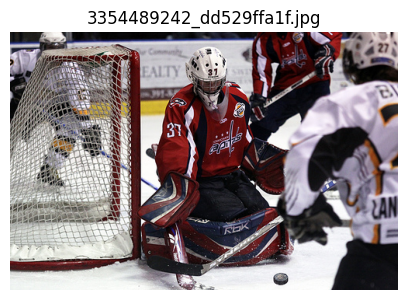

- a goalie tries to block the puck in a hockey game
- a hockey goalie stops the puck
- people playing hockey
- several hockey players move toward the puck next to a goal
- two hockey teams compete


In [6]:
example_name = random.choice(image_names)

plt.figure(figsize=(5, 5))
plt.imshow(load_img(IMAGE_DIR / example_name))
plt.axis("off")
plt.title(example_name)
plt.show()

for caption in captions_by_image[example_name]:
    print("-", caption.replace("startseq ", "").replace(" endseq", ""))


## 5. Split by image

Splitting by image keeps captions for the same picture from leaking across train, validation, and test sets.


In [7]:
train_images, test_images = train_test_split(
    image_names,
    test_size=0.20,
    random_state=SEED_VALUE,
    shuffle=True,
)

train_images, validation_images = train_test_split(
    train_images,
    test_size=0.10,
    random_state=SEED_VALUE,
    shuffle=True,
)

print("Train images:", len(train_images))
print("Validation images:", len(validation_images))
print("Test images:", len(test_images))


Train images: 5824
Validation images: 648
Test images: 1619


## 6. Extract MobileNetV2 image features

The first run can take a while. The features are saved to artifacts/mobilenetv2_features.pkl so later runs can load them quickly.


In [8]:
def build_feature_extractor():
    cnn_encoder = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
    cnn_encoder.trainable = False
    return cnn_encoder


def load_image_batch(batch_names, target_size=(224, 224)):
    arrays = []
    valid_names = []
    for filename in batch_names:
        try:
            photo = load_img(IMAGE_DIR / filename, target_size=target_size)
            arrays.append(img_to_array(photo))
            valid_names.append(filename)
        except Exception as error:
            print(f"Skipping {filename}: {error}")
    if not arrays:
        return valid_names, np.empty((0, *target_size, 3), dtype="float32")
    return valid_names, preprocess_input(np.asarray(arrays, dtype="float32"))


def get_image_features(all_names, batch_size=64):
    if FEATURE_FILE.exists():
        with open(FEATURE_FILE, "rb") as file:
            feature_lookup = pickle.load(file)
        missing = [name for name in all_names if name not in feature_lookup]
        if not missing:
            print("Loaded cached features:", len(feature_lookup))
            return feature_lookup
        print("Extracting missing features:", len(missing))
    else:
        feature_lookup = {}
        missing = list(all_names)

    cnn_encoder = build_feature_extractor()
    for start in range(0, len(missing), batch_size):
        batch_names = missing[start:start + batch_size]
        valid_names, image_array = load_image_batch(batch_names)
        if len(valid_names) == 0:
            continue
        features = cnn_encoder.predict(image_array, verbose=0)
        for filename, vector in zip(valid_names, features):
            feature_lookup[filename] = vector.astype("float32")
        print(f"Processed {min(start + batch_size, len(missing))}/{len(missing)} images")

    with open(FEATURE_FILE, "wb") as file:
        pickle.dump(feature_lookup, file)
    print("Saved features to", FEATURE_FILE)
    return feature_lookup

image_feature_map = get_image_features(image_names)
feature_length = next(iter(image_feature_map.values())).shape[0]
print("Feature length:", feature_length)


C:\Users\joann\AppData\Local\Temp\ipykernel_16620\2238731309.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_encoder = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Processed 64/8091 images
Processed 128/8091 images
Processed 192/8091 images
Processed 256/8091 images
Processed 320/8091 images
Processed 384/8091 images
Processed 448/8091 images
Processed 512/8091 images
Processed 576/8091 images
Processed 640/8091 images
Processed 704/8091 images
Processed 768/8091 images
Processed 832/8091 images
Processed 896/8091 images
Processed 960/8091 images
Processed 1024/8091 images
Processed 1088/8091 images
Processed 1152/8091 images
Processed 1216/8091 images
Processed 1280/8091 images
Processed 1344/8091 images
Processed 1408/8091 images
Processed 1472/8091 images
Processed 1536/8091 images
Processed 1600/8091 images
Processed 1664/8091 images
Processed 1728/8091 images
Processed 1792/8091 images
Processed 1856/8091 images
Processed 1920/8091 images
Processed 1984/8091 images
Processed 2048/8091 images
Processed 2112/8091 images
Processed 2176/8091 images
Processed 2240/8091 images
Processed 2304/8091 im

## 7. Tokenize captions and save deployment artifacts


In [9]:
caption_tokenizer = Tokenizer(oov_token="<unk>")
caption_tokenizer.fit_on_texts(caption_texts)

vocab_size = len(caption_tokenizer.word_index) + 1
max_caption_length = max(len(caption.split()) for caption in caption_texts)

with open(TOKENIZER_FILE, "wb") as file:
    pickle.dump(caption_tokenizer, file)

caption_config = {
    "vocab_size": vocab_size,
    "max_caption_length": max_caption_length,
    "feature_length": feature_length,
    "image_size": (224, 224),
    "start_token": "startseq",
    "end_token": "endseq",
}
with open(CONFIG_FILE, "wb") as file:
    pickle.dump(caption_config, file)

print("Vocabulary size:", vocab_size)
print("Maximum caption length:", max_caption_length)
print("Saved tokenizer and config in", ARTIFACT_DIR)


Vocabulary size: 8445
Maximum caption length: 38
Saved tokenizer and config in c:\image_caption_generator\artifacts


## 8. Create training batches

Each sample uses an image feature vector plus a partial caption to predict the next word.


In [10]:
class CaptionSequence(Sequence):
    def __init__(self, selected_images, caption_lookup, feature_lookup, tokenizer, sequence_length, vocabulary_size, batch_size=128, shuffle=True):
        self.selected_images = list(selected_images)
        self.caption_lookup = caption_lookup
        self.feature_lookup = feature_lookup
        self.tokenizer = tokenizer
        self.sequence_length = sequence_length
        self.vocabulary_size = vocabulary_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.samples = []
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):
        self.samples = []
        for filename in self.selected_images:
            for caption in self.caption_lookup[filename]:
                token_ids = self.tokenizer.texts_to_sequences([caption])[0]
                for split_at in range(1, len(token_ids)):
                    self.samples.append((filename, token_ids[:split_at], token_ids[split_at]))
        if self.shuffle:
            random.shuffle(self.samples)

    def __getitem__(self, batch_index):
        batch_samples = self.samples[batch_index * self.batch_size:(batch_index + 1) * self.batch_size]
        image_batch = np.zeros((len(batch_samples), feature_length), dtype="float32")
        text_batch = np.zeros((len(batch_samples), self.sequence_length), dtype="int32")
        target_batch = np.zeros((len(batch_samples), self.vocabulary_size), dtype="float32")

        for row_index, (filename, partial_caption, next_word) in enumerate(batch_samples):
            image_batch[row_index] = self.feature_lookup[filename]
            text_batch[row_index] = pad_sequences([partial_caption], maxlen=self.sequence_length, padding="post")[0]
            target_batch[row_index] = to_categorical(next_word, num_classes=self.vocabulary_size)

        return {"image_features": image_batch, "caption_tokens": text_batch}, target_batch

train_sequence = CaptionSequence(train_images, captions_by_image, image_feature_map, caption_tokenizer, max_caption_length, vocab_size)
validation_sequence = CaptionSequence(validation_images, captions_by_image, image_feature_map, caption_tokenizer, max_caption_length, vocab_size, shuffle=False)

print("Train batches:", len(train_sequence))
print("Validation batches:", len(validation_sequence))


Train batches: 2687
Validation batches: 302


## 9. Build and train the CNN + LSTM caption model

The CNN features are already extracted by MobileNetV2. The LSTM learns caption language patterns and combines them with the image features.


In [11]:
def build_caption_model(feature_count, vocabulary_count, sequence_length, embedding_size=256, hidden_size=256):
    image_input = Input(shape=(feature_count,), name="image_features")
    image_branch = Dropout(0.35)(image_input)
    image_branch = Dense(hidden_size, activation="relu")(image_branch)

    caption_input = Input(shape=(sequence_length,), name="caption_tokens")
    caption_branch = Embedding(vocabulary_count, embedding_size, mask_zero=True)(caption_input)
    caption_branch = Dropout(0.35)(caption_branch)
    caption_branch = LSTM(hidden_size)(caption_branch)

    merged = Add()([image_branch, caption_branch])
    merged = Dense(hidden_size, activation="relu")(merged)
    output_word = Dense(vocabulary_count, activation="softmax", name="next_word")(merged)

    model = Model(inputs=[image_input, caption_input], outputs=output_word)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

caption_model = build_caption_model(feature_length, vocab_size, max_caption_length)
caption_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_tokens      │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,161,920 │ caption_tokens[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ caption_tokens[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_word (Dense)   │ (None, 8445)      │  2,170,365 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,251,325 (20.03 MB)

 Trainable params: 5,251,325 (20.03 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS_TO_RUN = 10

callbacks = [
    ModelCheckpoint(MODEL_FILE, monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

history = caption_model.fit(
    train_sequence,
    validation_data=validation_sequence,
    epochs=EPOCHS_TO_RUN,
    callbacks=callbacks,
)

caption_model.save(MODEL_FILE)
print("Saved model to", MODEL_FILE)


c:\image_caption_generator\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2687/2687 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.2659 - loss: 4.4070
Epoch 1: val_loss improved from None to 3.46040, saving model to c:\image_caption_generator\artifacts\caption_model.keras

Epoch 1: finished saving model to c:\image_caption_generator\artifacts\caption_model.keras
2687/2687 ━━━━━━━━━━━━━━━━━━━━ 366s 136ms/step - accuracy: 0.3160 - loss: 3.8602 - val_accuracy: 0.3622 - val_loss: 3.4604 - learning_rate: 0.0010
Epoch 2/10
2687/2687 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3714 - loss: 3.1472
Epoch 2: val_loss improved from 3.46040 to 3.32304, saving model to c:\image_caption_generator\artifacts\caption_model.keras

Epoch 2: finished saving model to c:\image_caption_generator\artifacts\caption_model.keras
2687/2687 ━━━━━━━━━━━━━━━━━━━━ 297s 111ms/step - accuracy: 0.3767 - loss: 3.0971 - val_accuracy: 0.3794 - val_loss: 3.3230 - learning_rate: 0.0010
Epoch 3/10
2687/2687 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3970 - loss: 2.8381
Epoch

## 10. Plot training performance


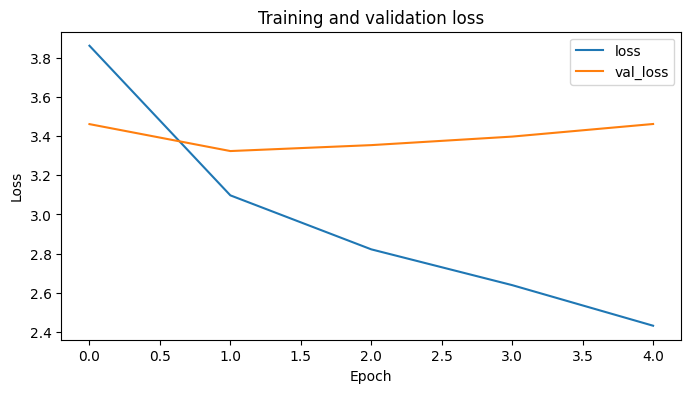

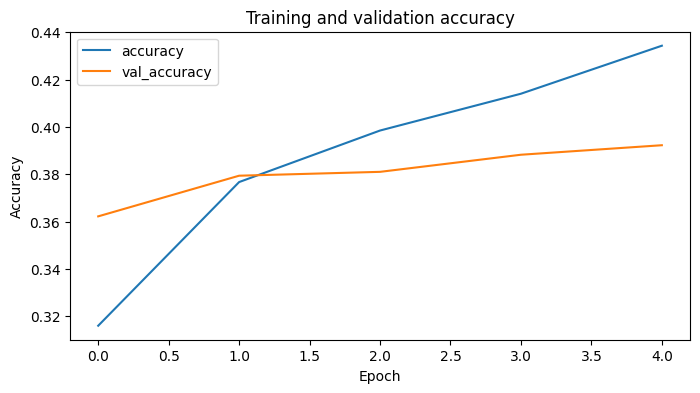

In [13]:
history_table = pd.DataFrame(history.history)
history_table[["loss", "val_loss"]].plot(figsize=(8, 4), title="Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

if "accuracy" in history_table.columns:
    history_table[["accuracy", "val_accuracy"]].plot(figsize=(8, 4), title="Training and validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()


## 11. Generate captions


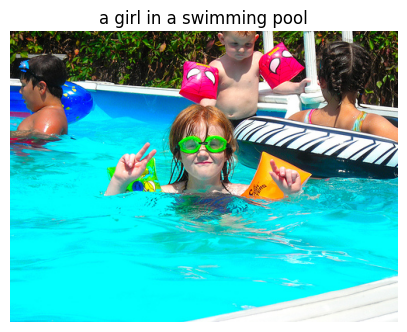

Predicted caption: a girl in a swimming pool
Reference captions:
- a girl in a pool wearing goggles and surrounded by other children
- a girl in green goggles in a pool with three other children
- a red haired girl making a peace sign is wearing neon green glasses and floaties and playing in the pool with other kids
- a red headed girl offers the peace sign as she swims in the pool with floaties
- a young girl with goggles and floaties poses for the camera as she plays in a pool


In [14]:
def word_from_id(tokenizer, token_id):
    return tokenizer.index_word.get(token_id)


def generate_caption(model, tokenizer, feature_vector, sequence_length):
    words = ["startseq"]
    for _ in range(sequence_length):
        token_ids = tokenizer.texts_to_sequences([" ".join(words)])[0]
        token_ids = pad_sequences([token_ids], maxlen=sequence_length, padding="post")
        probabilities = model.predict(
            {"image_features": np.asarray([feature_vector]), "caption_tokens": token_ids},
            verbose=0,
        )
        predicted_id = int(np.argmax(probabilities))
        predicted_word = word_from_id(tokenizer, predicted_id)
        if predicted_word is None:
            break
        words.append(predicted_word)
        if predicted_word == "endseq":
            break
    return " ".join(words).replace("startseq", "").replace("endseq", "").strip()


def extract_feature_for_uploaded_image(image_path):
    cnn_encoder = build_feature_extractor()
    photo = load_img(image_path, target_size=(224, 224))
    photo_array = img_to_array(photo)
    photo_array = np.expand_dims(photo_array, axis=0)
    photo_array = preprocess_input(photo_array)
    return cnn_encoder.predict(photo_array, verbose=0)[0]

best_caption_model = load_model(MODEL_FILE)
preview_name = random.choice(test_images)
predicted_caption = generate_caption(best_caption_model, caption_tokenizer, image_feature_map[preview_name], max_caption_length)

plt.figure(figsize=(5, 5))
plt.imshow(load_img(IMAGE_DIR / preview_name))
plt.axis("off")
plt.title(predicted_caption)
plt.show()

print("Predicted caption:", predicted_caption)
print("Reference captions:")
for caption in captions_by_image[preview_name]:
    print("-", caption.replace("startseq ", "").replace(" endseq", ""))


## 12. BLEU evaluation

BLEU is a quick text-overlap score. It is useful for comparing model versions, but it does not always match human judgment perfectly.


In [15]:
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

    actual = []
    predicted = []
    smoothing = SmoothingFunction().method1

    for filename in test_images[:250]:
        references = [caption.replace("startseq ", "").replace(" endseq", "").split() for caption in captions_by_image[filename]]
        generated = generate_caption(best_caption_model, caption_tokenizer, image_feature_map[filename], max_caption_length).split()
        actual.append(references)
        predicted.append(generated)

    print("BLEU-1:", corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0), smoothing_function=smoothing))
    print("BLEU-2:", corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing))
except ImportError:
    print("Install nltk to run BLEU: %pip install nltk")


BLEU-1: 0.528261642374689
BLEU-2: 0.3493100564300191
